# MAPK cascade with a kinase inhibitor

Simulations use [bngsim](https://bngsim.readthedocs.io), which loads BioNetGen models directly and runs ODE and stochastic (SSA) simulations in-process. `bngsim.Model.from_bngl` generates the reaction network with BioNetGen and loads it; the `simulate` actions at the end of the `.bngl` file are not run.

Two things to remember:
- Parameters are changed on the **model** (`model.set_param`), and simulations are run by a **simulator** (`sim.run`).
- A run starts from the model's *current* state. Call `model.reset()` before each run to start from the initial conditions (this also applies new initial-condition parameters such as `L0`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bngsim

# Load model from BNGL
infile = "../models/mapk3_inh.bngl"
model = bngsim.Model.from_bngl(infile)
sim = bngsim.Simulator(model, method="ode")

## Run a single simulation and plot the results

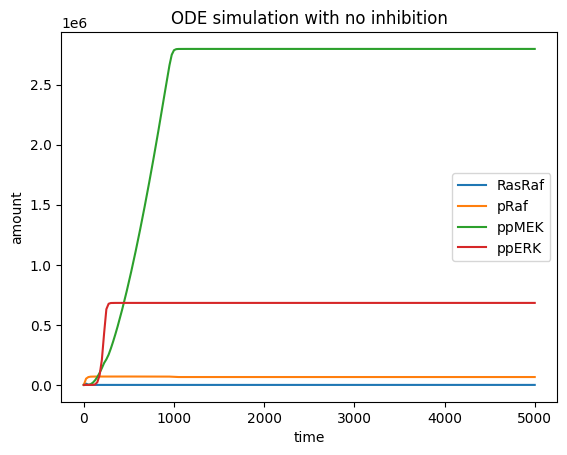

In [2]:
onames = model.observable_names
model.set_param('kin_inh_factor', 1.0)   # no inhibition
model.reset()
res1 = sim.run(t_span=(0, 5000), n_points=201)

for o in onames:
    plt.plot(res1.time, res1.observables[o], label=o)
plt.title("ODE simulation with no inhibition")
plt.xlabel('time')
plt.ylabel('amount')
_ = plt.legend()

## Compare results of multiple simulations

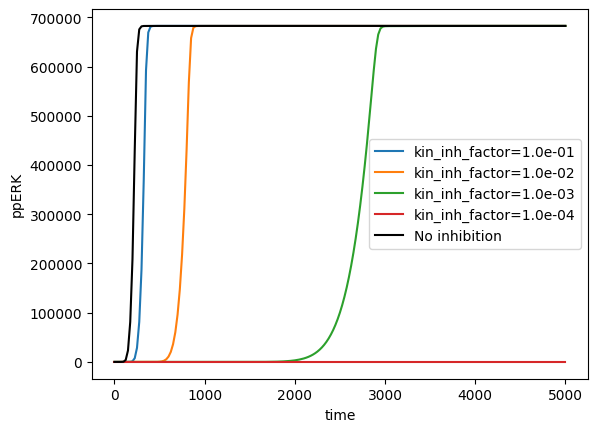

In [3]:
pname = 'kin_inh_factor'
o = 'ppERK'
out = []
krange = np.logspace(-1, -4, 4)
for k in krange:
    model.set_param(pname, k)
    model.reset()
    res2 = sim.run(t_span=(0, 5000), n_points=201)
    out.append(res2.observables[o][-1])
    plt.plot(res2.time, res2.observables[o], label=f'{pname}={k:0.1e}')
plt.plot(res1.time, res1.observables[o], 'k', label='No inhibition')
plt.xlabel('time')
plt.ylabel(o)
_ = plt.legend(loc='best')

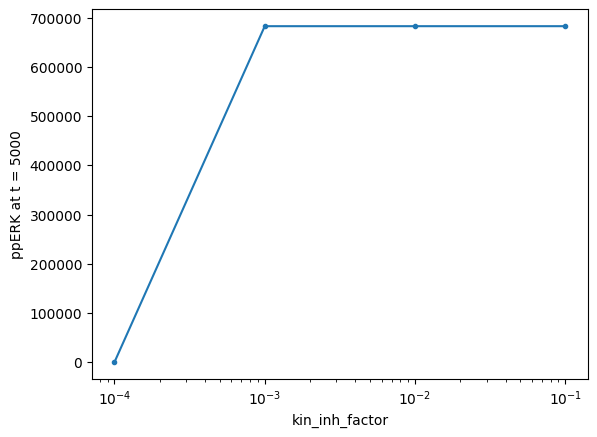

In [4]:
plt.semilogx(krange, out, '.-')
plt.xlabel(pname)
_ = plt.ylabel(f'{o} at t = 5000')